<a href="https://colab.research.google.com/github/juliamunoz103-code/IAveranos2026/blob/main/Final_Project_Team1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Final Project.- Training a Machine Learning model on medical images**
Class Schedule: V4-V6 LMMJV

Pablo Andrés Villarreal Cárdenas 2043233

Andrea Sofía Cantú Trejo 2120574

Julia Aracely Muñoz González 2094919

Oscar Daniel Cruz Cruz 2094531

# **Part 1: Load libraries**

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import datasets, layers, models
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
from sklearn.model_selection import train_test_split
import zipfile
from sklearn.metrics import classification_report

# **Part 2: Downloading data**

In [ ]:
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_125205ea7f364ec6b025aaaae533793f'
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [05:06<00:00, 18.2MB/s]



In [ ]:
with zipfile.ZipFile("skin-cancer-mnist-ham10000.zip", "r") as zip_ref:
    zip_ref.extractall("HAM10000")

ruta_dataset = "HAM10000"
print("Archivos extraidos en:", ruta_dataset)

Archivos extraidos en: HAM10000


# **Part 3: Loading data**

In [ ]:
metadata = pd.read_csv(os.path.join(ruta_dataset, "HAM10000_metadata.csv"))
metadata.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [ ]:
rutas_imagenes = {
    os.path.splitext(os.path.basename(ruta))[0]: ruta
    for ruta in glob.glob(os.path.join(ruta_dataset, "*", "*.jpg"))
}

print("Imagenes encontradas:", len(rutas_imagenes))

metadata["ruta_imagen"] = metadata["image_id"].map(rutas_imagenes)
metadata.head()

Imagenes encontradas: 10015


,lesion_id,image_id,dx,dx_type,age,sex,localization,ruta_imagen
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,HAM10000/ham10000_images_part_1/ISIC_0027419.jpg
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,HAM10000/ham10000_images_part_1/ISIC_0025030.jpg
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,HAM10000/ham10000_images_part_1/ISIC_0026769.jpg
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,HAM10000/ham10000_images_part_1/ISIC_0025661.jpg
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,HAM10000/HAM10000_images_part_2/ISIC_0031633.jpg


In [ ]:
class_names = metadata["dx"].unique()
print("Clases:", class_names)

dx_label = {"nv": 0, "mel": 1, "bkl": 2, "bcc": 3, "akiec": 4, "vasc": 5, "df": 6}

metadata["label"] = metadata["dx"].map(dx_label)
metadata["dx"].value_counts()

Clases: ['bkl' 'nv' 'df' 'mel' 'vasc' 'bcc' 'akiec']


,count
dx,
nv,6705
mel,1113
bkl,1099
bcc,514
akiec,327
vasc,142
df,115


In [ ]:
lista_imagenes = []
for ruta in metadata["ruta_imagen"]:
    contenido = tf.io.read_file(ruta)
    imagen = tf.image.decode_jpeg(contenido, channels = 3)
    imagen = tf.image.resize(imagen, [128, 128])
    lista_imagenes.append(imagen.numpy().astype("uint8"))

imagenes = np.stack(lista_imagenes)
etiquetas = metadata["label"].values

print(imagenes.shape)

(10015, 128, 128, 3)


In [ ]:
train_images, test_images, train_labels, test_labels = train_test_split(imagenes, etiquetas, test_size = 0.3, random_state = 42)

# **Part 4: Preprocessing**

In [ ]:
train_images = train_images / 255.0
test_images = test_images / 255.0

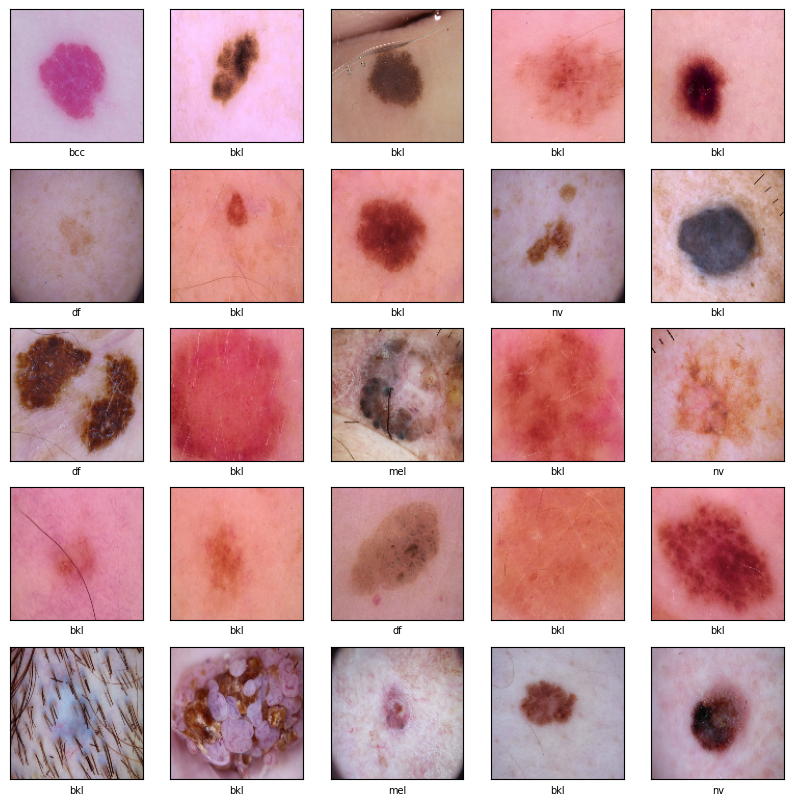

In [ ]:
plt.figure(figsize = (10, 10))
for i in range(25):
  plt.subplot(5, 5, i + 1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(train_images[i])
  plt.xlabel(class_names[train_labels[i]], fontsize = 7)
plt.show()

# **Part 5: Model selection and training**

In [ ]:
model = models.Sequential()

model.add(layers.RandomFlip("horizontal_and_vertical", input_shape = (128, 128, 3)))
model.add(layers.RandomRotation(0.2))
model.add(layers.RandomZoom(0.1))

model.add(layers.Conv2D(32, (3, 3), activation = "relu"))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation = "relu"))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation = "relu"))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.add(layers.Flatten())
model.add(layers.Dense(128, activation = "relu"))
model.add(layers.Dense(7, activation = "softmax"))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,663,623 (6.35 MB)

 Trainable params: 1,663,303 (6.34 MB)

 Non-trainable params: 320 (1.25 KB)

In [ ]:
model.compile(optimizer = "adam", loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits = True), metrics = ["accuracy"])

history = model.fit(train_images, train_labels, epochs = 20, validation_data = (test_images, test_labels))

Epoch 1/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 14s 52ms/step - accuracy: 0.8147 - loss: 0.5060 - val_accuracy: 0.7012 - val_loss: 1.1950
Epoch 2/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - accuracy: 0.8198 - loss: 0.4948 - val_accuracy: 0.7235 - val_loss: 0.8988
Epoch 3/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.8100 - loss: 0.5050 - val_accuracy: 0.7394 - val_loss: 0.8338
Epoch 4/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - accuracy: 0.8175 - loss: 0.4848 - val_accuracy: 0.7401 - val_loss: 0.9772
Epoch 5/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - accuracy: 0.8150 - loss: 0.4938 - val_accuracy: 0.4223 - val_loss: 28.8466
Epoch 6/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - accuracy: 0.8204 - loss: 0.4810 - val_accuracy: 0.7707 - val_loss: 0.6806
Epoch 7/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - accuracy: 0.8290 - loss: 0.4760 - val_accuracy: 0.7281 - val_loss: 0.8960
Epoch 8/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - accuracy: 0.8234 - loss: 0.4778 -

In [ ]:
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

94/94 - 1s - 12ms/step - accuracy: 0.7328 - loss: 0.8740


In [ ]:
predictions = model.predict(test_images)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


In [ ]:
for i in range(10):
  print(f"Prediction result: {np.argmax(predictions[i])}")
  print(f"Actual result: {test_labels[i]}\n")

Prediction result: 2
Actual result: 1

Prediction result: 0
Actual result: 0

Prediction result: 6
Actual result: 1

Prediction result: 2
Actual result: 2

Prediction result: 0
Actual result: 0

Prediction result: 2
Actual result: 0

Prediction result: 0
Actual result: 0

Prediction result: 2
Actual result: 0

Prediction result: 2
Actual result: 1

Prediction result: 0
Actual result: 0



In [ ]:
pred_labels = np.argmax(model.predict(test_images), axis=1)
print(classification_report(test_labels, pred_labels))

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1997
           1       0.80      0.11      0.20       347
           2       0.39      0.73      0.50       350
           3       0.57      0.56      0.57       143
           4       0.52      0.12      0.20        96
           5       0.85      0.52      0.64        33
           6       0.25      0.26      0.25        39

    accuracy                           0.73      3005
   macro avg       0.61      0.46      0.46      3005
weighted avg       0.77      0.73      0.71      3005



94/94 - 1s - 11ms/step - accuracy: 0.7328 - loss: 0.8740


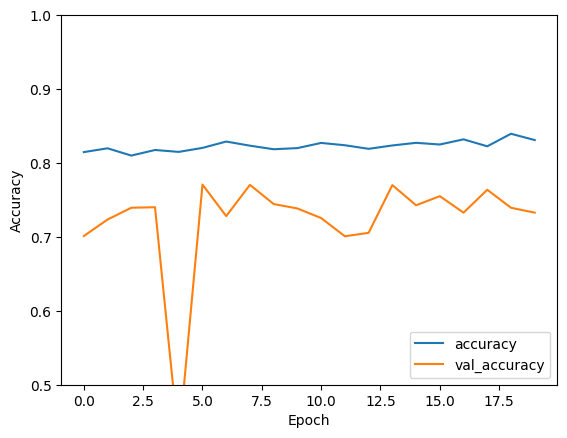

In [ ]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)